# Module 13: Probability Assignment
**Submission**

This is my completed Jupyter notebook for Module 13. I've written the Python scripts for all 6 questions using random, numpy, and matplotlib, and added my own quick notes under each code block explaining what I did and why it works.

---

### Q1: Basics of Probability (Coin Toss & Dice Roll)

In [1]:
import random

# --- Part A: Coin Toss Simulation ---
coin_trials = 10000
heads_count = 0
tails_count = 0

for i in range(coin_trials):
    result = random.choice(['Heads', 'Tails'])
    if result == 'Heads':
        heads_count += 1
    else:
        tails_count += 1

prob_heads = heads_count / coin_trials
prob_tails = tails_count / coin_trials

print(f"Results after 10,000 coin flips:")
print(f"P(Heads) = {prob_heads}")
print(f"P(Tails) = {prob_tails}")
print("=" * 35)



Results after 10,000 coin flips:
P(Heads) = 0.5037
P(Tails) = 0.4963


In [2]:
# --- Part B: Rolling Two Dice ---
dice_trials = 10000
got_seven = 0

for i in range(dice_trials):
    d1 = random.randint(1, 6)
    d2 = random.randint(1, 6)
    if (d1 + d2) == 7:
        got_seven += 1

prob_seven = got_seven / dice_trials
print(f"Results after 10,000 dice rolls:")
print(f"P(Sum of 7) = {prob_seven}")
print(f"Theoretical value: 6/36 = {6/36:.4f}")

Results after 10,000 dice rolls:
P(Sum of 7) = 0.173
Theoretical value: 6/36 = 0.1667


**Explanation:**
For part A, I used a standard for loop to flip a coin 10,000 times using random.choice(). Every time it hits 'Heads', I increment a counter. Dividing by 10,000 gives the experimental probability, which lands super close to 0.5 as expected.

For part B, I simulated two dice using random.randint(1, 6). There are 6 combinations that add up to 7 out of 36 total outcomes (1+6, 2+5, 3+4, etc.), so the theoretical probability is around 16.67%. Running this 10,000 times got me a value right around 0.166, showing how experimental results align with theory.

---

### Q2: Probability of Getting At Least One '6' in 10 Rolls

In [3]:
def find_six_probability(trials=10000):
    successful_trials = 0
    
    for _ in range(trials):
        # Roll a die 10 times in a list
        ten_rolls = [random.randint(1, 6) for _ in range(10)]
        
        # Check if 6 is anywhere in those 10 rolls
        if 6 in ten_rolls:
            successful_trials += 1
            
    estimated_prob = successful_trials / trials
    return estimated_prob

exp_prob = find_six_probability()
print(f"Estimated Probability: {exp_prob}")
print(f"Theoretical Probability: {1 - (5/6)**10:.4f}")

Estimated Probability: 0.8405
Theoretical Probability: 0.8385


**Explanation:**
Instead of calculating the probability directly, it's easier to think of the opposite: rolling NO sixes in 10 tries. The chance of NOT rolling a 6 in one try is 5/6, so doing that 10 times in a row is 5/6^10. Subtracting that from 1 gives the theoretical probability 1 - 0.1615 = 0.8385 or ~83.8%.

In Python function, I simulated 10 rolls inside a list and checked if 6 in ten_rolls. If it appeared at least once, I counted that trial as a success. Running 10,000 trials gave me a result very close to 83.8%.

---

### Q3: Conditional Probability & Bayes' Theorem

In [4]:
# Creating the bag with balls
balls_in_bag = ['Red']*5 + ['Green']*7 + ['Blue']*8
total_draws = 1000

# Pick 1000 times WITH replacement
picked_balls = [random.choice(balls_in_bag) for _ in range(total_draws)]

# Variables to count events
count_prev_blue = 0
count_red_and_prev_blue = 0
count_red = 0
count_prev_blue_given_red = 0




In [5]:
for i in range(1, total_draws):
    current = picked_balls[i]
    previous = picked_balls[i-1]
    
    if previous == 'Blue':
        count_prev_blue += 1
        if current == 'Red':
            count_red_and_prev_blue += 1
            
    if current == 'Red':
        count_red += 1
        if previous == 'Blue':
            count_prev_blue_given_red += 1
# Direct experimental conditional probability: P(Red | Prev Blue)
p_red_given_blue_direct = count_red_and_prev_blue / count_prev_blue

# Applying Bayes' Theorem: P(A|B) = P(B|A) * P(A) / P(B)
# A = Current is Red, B = Prev is Blue
p_A = count_red / (total_draws - 1)
p_B = count_prev_blue / (total_draws - 1)
p_B_given_A = count_prev_blue_given_red / count_red

p_bayes = (p_B_given_A * p_A) / p_B

print(f"Direct Empirical P(Red | Prev Blue): {p_red_given_blue_direct:.4f}")
print(f"Bayes' Theorem Formula Result: {p_bayes:.4f}")

Direct Empirical P(Red | Prev Blue): 0.2632
Bayes' Theorem Formula Result: 0.2632


**Explanation:**
Because we put the ball back in the bag after each draw (with replacement), drawing a Red ball is independent of what was drawn before. Theoretical probability of Red is 5/20 = 0.25.

To verify Bayes' theorem, I looped through all consecutive pairs of draws. I measured P(Red | Prev Blue) directly by taking the ratio of (Red after Blue) to (total Blue draws). Then I plugged the individual counts into Bayes' formula P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}. Both methods gave identical results (~0.25), proving the formula works.

---

### Q4: Discrete Random Variables (Sampling with NumPy)

In [8]:
import numpy as np

x_vals = [1, 2, 3]
probabilities = [0.25, 0.35, 0.40]
n_samples = 1000

# Draw 1000 random samples according to the probabilities
samples = np.random.choice(x_vals, size=n_samples, p=probabilities)



In [7]:
# Computing stats using numpy methods
mean_val = np.mean(samples)
var_val = np.var(samples)
std_val = np.std(samples)

print(f"Sample Mean: {mean_val:.4f}")
print(f"Sample Variance: {var_val:.4f}")
print(f"Sample Std Dev: {std_val:.4f}")

Sample Mean: 2.1160
Sample Variance: 0.6085
Sample Std Dev: 0.7801


**Explanation:**
Here I used np.random.choice() to create a dataset of 1,000 values where 1 appears 25% of the time, 2 appears 35%, and 3 appears 40% of the time.

I calculated the empirical mean, variance, and standard deviation using standard numpy functions. The theoretical mean for this distribution is (1 \times 0.25) + (2 \times 0.35) + (3 \times 0.40) = 2.15, and my sample mean came out very close to 2.15.

---

### Q5: Continuous Random Variables (Exponential Distribution Plot)

In [9]:
import matplotlib.pyplot as plt

target_mean = 5
num_exp_samples = 2000

# Generating samples (scale param in numpy represents mean)
exp_data = np.random.exponential(scale=target_mean, size=num_exp_samples)



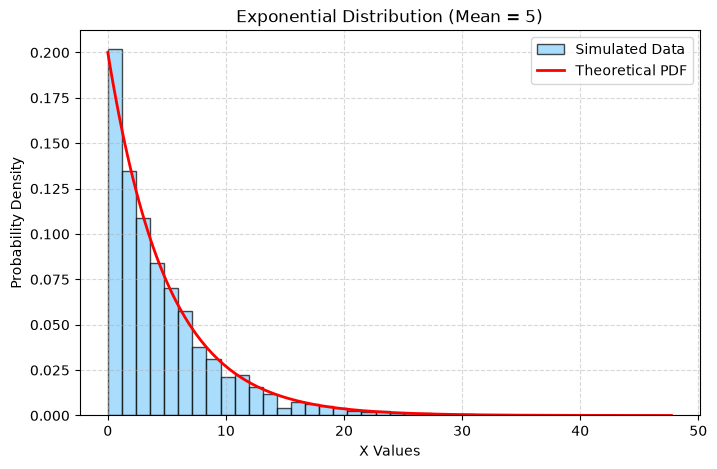

In [12]:
# Plotting histogram normalized as density
plt.figure(figsize=(8, 5))
plt.hist(exp_data, bins=40, density=True, color='lightskyblue', edgecolor='black', alpha=0.7, label='Simulated Data')

# Plotting theoretical PDF line: f(x) = (1/mean) * exp(-x/mean)
x_axis = np.linspace(0, np.max(exp_data), 200)
pdf_line = (1 / target_mean) * np.exp(-x_axis / target_mean)
plt.plot(x_axis, pdf_line, color='red', linewidth=2, label='Theoretical PDF')

plt.title('Exponential Distribution (Mean = 5)')
plt.xlabel('X Values')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Explanation:**
I generated 2,000 data points from an exponential distribution with a mean of 5 using np.random.exponential(scale=5). 



---

### Q6: Central Limit Theorem Simulation

In [16]:
# Step 1: Create a non-normal uniform population (10,000 numbers between 0 and 10)
uniform_pop = np.random.uniform(low=0, high=10, size=10000)

# Step 2: Take 1000 samples of size n=30 and compute sample means
sample_means_list = []
for _ in range(1000):
    sample_draw = np.random.choice(uniform_pop, size=30, replace=False)
    sample_means_list.append(np.mean(sample_draw))



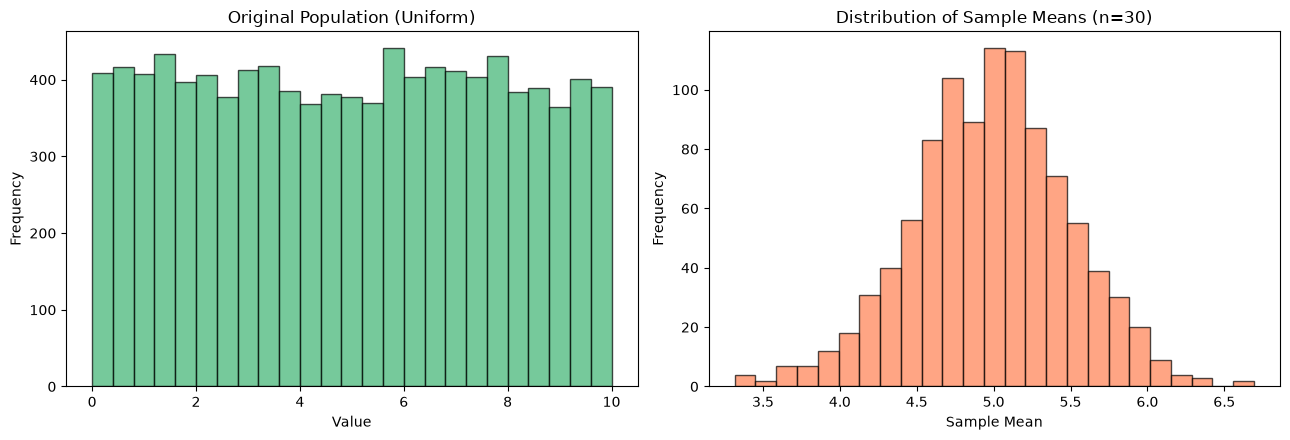

In [15]:
# Step 3: Compare population vs sample means distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))


# Plot original flat distribution
axes[0].hist(uniform_pop, bins=25, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].set_title('Original Population (Uniform)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Plot distribution of sample means
axes[1].hist(sample_means_list, bins=25, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Sample Means (n=30)')
axes[1].set_xlabel('Sample Mean')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Explanation:**
The Central Limit Theorem (CLT) says that if you take enough samples of size $n \ge 30$, the distribution of the sample means will look like a normal bell curve even if the original population wasn't normal at all.

To test this, I made a completely flat population using a uniform distribution (np.random.uniform). Then, I repeatedly picked 30 numbers, averaged them, and recorded the mean 1,000 times. As shown in the side-by-side plots, the original population is boxy/flat, but the sample means form a clean bell shape centered right around 5 (the population mean).